# Cart-Pole Swing-up: Energy Shaping + LQR

In [1]:
from copy import copy

import matplotlib.pyplot as plt
import numpy as np
from pydrake.all import (
    AddMultibodyPlantSceneGraph,
    DiagramBuilder,
    LeafSystem,
    Linearize,
    LinearQuadraticRegulator,
    MeshcatVisualizer,
    Parser,
    Saturation,
    Simulator,
    StartMeshcat,
    VectorLogSink,
    wrap_to,
)

from underactuated import ConfigureParser, running_as_notebook
from underactuated.utils import running_as_test

np.set_printoptions(formatter={"float": lambda x: "{0:0.4f}".format(x)})

In [2]:
# Start the visualizer. Run this cell only once; each instance consumes a port.
meshcat = StartMeshcat()

INFO:drake:Meshcat listening for connections at http://localhost:7001


## Coordinates and energy

In [3]:
CARTPOLE_URDF = "package://underactuated/models/undamped_cartpole.urdf"
UPRIGHT_STATE = np.array([0.0, np.pi, 0.0, 0.0])


def UprightStateError(x):
    xbar = copy(x)
    xbar[1] = wrap_to(xbar[1], 0.0, 2.0 * np.pi) - np.pi
    return xbar


def PendulumEnergy(x, g=9.81):
    theta = x[1]
    thetadot = x[3]
    return 0.5 * thetadot**2 - g * np.cos(theta)


def UprightPendulumEnergy(g=9.81):
    return g

## Energy shaping controller

This is the nonlinear swing-up controller.  Notice that it is just a Drake `LeafSystem`: it takes the cart-pole state and outputs a cart force.

In [ ]:
class CartPoleEnergyShapingController(LeafSystem):
    def __init__(self, kE=4.0, kp=1.0, kd=2.0, g=9.81):
        LeafSystem.__init__(self)
        self.DeclareVectorInputPort("state", 4)
        self.DeclareVectorOutputPort("force", 1, self.DoCalcOutput)

        self.kE = kE
        self.kp = kp
        self.kd = kd
        self.g = g
        self.desired_energy = UprightPendulumEnergy(g)

    def CalcForce(self, x):
        q, theta, qdot, thetadot = x
        s = np.sin(theta)
        c = np.cos(theta)

        energy_error = PendulumEnergy(x, self.g) - self.desired_energy

        # Collocated partial feedback linearization says: choose the desired
        # cart acceleration, then map it back to the physical cart force.
        qddot_des = (
            self.kE * thetadot * c * energy_error
            - self.kp * q
            - self.kd * qdot
        )
        return (1.0 + s**2) * qddot_des - s * (thetadot**2 + self.g * c)

    def DoCalcOutput(self, context, output):
        cartpole_state = self.get_input_port(0).Eval(context)
        output.SetAtIndex(0, self.CalcForce(cartpole_state))

## Swing-up and balance

The swing-up controller is global and nonlinear.  The LQR controller is local, but it is very reliable once the state is reasonably close to the upright equilibrium.

Here the balancing part is intentionally written closer to Russ's `cartpole_balancing` notebook: set an upright operating context on the Drake cart-pole, fix the equilibrium input to zero, and use the simple weights \(Q=I, R=I\).  The extra `Linearize` call is only here because the switching rule also wants the Riccati matrix \(S\).


In [ ]:
def BalancingLQR(cartpole, Q=None, R=None):
    if Q is None:
        Q = np.eye(4)
    if R is None:
        R = np.eye(1)

    context = cartpole.CreateDefaultContext()
    context.get_mutable_continuous_state_vector().SetFromVector(UPRIGHT_STATE)

    cartpole.get_actuation_input_port().FixValue(context, [0.0])
    input_i = cartpole.get_actuation_input_port().get_index()

    _ = LinearQuadraticRegulator(
        cartpole,
        context,
        Q,
        R,
        input_port_index=input_i,
    )

    output_i = cartpole.get_state_output_port().get_index()
    cartpole_lin = Linearize(
        cartpole,
        context,
        input_port_index=input_i,
        output_port_index=output_i,
    )

    K, S = LinearQuadraticRegulator(cartpole_lin.A(), cartpole_lin.B(), Q, R)
    return K, S


class SwingUpAndBalanceController(LeafSystem):
    def __init__(self, cartpole, rho=100.0, kE=4.0, kp=1.0, kd=2.0):
        LeafSystem.__init__(self)
        self.DeclareVectorInputPort("state", 4)
        self.DeclareVectorOutputPort("force", 1, self.DoCalcOutput)

        self.K, self.S = BalancingLQR(cartpole)
        self.rho = rho

        self.energy_shaping = CartPoleEnergyShapingController(kE=kE, kp=kp, kd=kd)
        self.energy_shaping_context = self.energy_shaping.CreateDefaultContext()

    def DoCalcOutput(self, context, output):
        cartpole_state = self.get_input_port(0).Eval(context)
        xbar = UprightStateError(cartpole_state)

        if xbar.dot(self.S.dot(xbar)) < self.rho:
            output.SetFromVector(-self.K.dot(xbar))
        else:
            self.energy_shaping.get_input_port(0).FixValue(
                self.energy_shaping_context, cartpole_state
            )
            output.SetFromVector(
                self.energy_shaping.get_output_port(0).Eval(
                    self.energy_shaping_context
                )
            )


## Build the diagram

In [6]:
def AddCartPole(builder):
    cartpole, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.0)
    parser = Parser(cartpole)
    ConfigureParser(parser)
    parser.AddModelsFromUrl(CARTPOLE_URDF)
    cartpole.Finalize()
    cartpole.set_name("cartpole")
    return cartpole, scene_graph


def MakeCartPoleSwingUpAndBalanceDiagram(
    rho=100.0,
    kE=4.0,
    kp=1.0,
    kd=2.0,
    force_limit=80.0,
):
    builder = DiagramBuilder()

    cartpole, scene_graph = AddCartPole(builder)

    controller = builder.AddSystem(
        SwingUpAndBalanceController(
            cartpole,
            rho=rho,
            kE=kE,
            kp=kp,
            kd=kd,
        )
    )
    controller.set_name("swing_up_and_balance_controller")

    saturation = builder.AddSystem(
        Saturation(min_value=[-force_limit], max_value=[force_limit])
    )
    saturation.set_name("force_saturation")

    builder.Connect(cartpole.get_state_output_port(), controller.get_input_port(0))
    builder.Connect(controller.get_output_port(0), saturation.get_input_port(0))
    builder.Connect(saturation.get_output_port(0), cartpole.get_actuation_input_port())

    state_logger = builder.AddSystem(VectorLogSink(4))
    state_logger.set_name("state_logger")
    builder.Connect(cartpole.get_state_output_port(), state_logger.get_input_port(0))

    force_logger = builder.AddSystem(VectorLogSink(1))
    force_logger.set_name("force_logger")
    builder.Connect(saturation.get_output_port(0), force_logger.get_input_port(0))

    meshcat.Delete()
    meshcat.Set2dRenderMode(xmin=-3.0, xmax=3.0, ymin=-1.0, ymax=2.5)
    visualizer = MeshcatVisualizer.AddToBuilder(builder, scene_graph, meshcat)
    visualizer.set_name("visualizer")

    diagram = builder.Build()
    return diagram, cartpole

## Simulate and plot

This cell is intentionally just the simulation machinery.  Keeping it separate makes the controller cells easier to read.

In [7]:
def SimulateCartPole(diagram, cartpole, x0, sim_time=10.0, show=False, record=True):
    simulator = Simulator(diagram)
    simulator.set_target_realtime_rate(1.0 if show else 0.0)

    context = simulator.get_mutable_context()
    context.SetTime(0.0)

    cartpole_context = cartpole.GetMyMutableContextFromRoot(context)
    cartpole.SetPositionsAndVelocities(cartpole_context, x0)

    visualizer = diagram.GetSubsystemByName("visualizer")
    if record:
        # Start with a clean recording, but keep live visualization enabled.
        # StartRecording(False) records silently; StartRecording(True) lets Meshcat
        # move while the simulation is running.
        visualizer.DeleteRecording()
        visualizer.StartRecording(True)

    simulator.Initialize()
    simulator.AdvanceTo(sim_time if running_as_notebook else min(sim_time, 0.1))

    if record:
        # Keep the recording in Meshcat so it can be replayed after the cell finishes.
        # Do not call DeleteRecording() here; that removes the animation you just made.
        visualizer.PublishRecording()

    state_logger = diagram.GetSubsystemByName("state_logger")
    force_logger = diagram.GetSubsystemByName("force_logger")
    return state_logger.FindLog(context), force_logger.FindLog(context)


def PlotCartPoleLog(state_log, force_log=None):
    t = state_log.sample_times()
    x = state_log.data()

    plt.figure(figsize=(8, 4))
    plt.plot(t, x[0, :], label="q")
    plt.plot(t, [UprightStateError(x[:, i])[1] for i in range(x.shape[1])], label="theta - pi")
    plt.plot(t, x[2, :], label="qdot")
    plt.plot(t, x[3, :], label="thetadot")
    plt.xlabel("time (s)")
    plt.ylabel("state")
    plt.legend()
    plt.grid(True)
    plt.show()

    energy_error = np.array(
        [PendulumEnergy(x[:, i]) - UprightPendulumEnergy() for i in range(x.shape[1])]
    )

    plt.figure(figsize=(8, 3))
    plt.plot(t, energy_error)
    plt.xlabel("time (s)")
    plt.ylabel("E - E_desired")
    plt.grid(True)
    plt.show()

    if force_log is not None:
        tf = force_log.sample_times()
        u = force_log.data()[0, :]

        plt.figure(figsize=(8, 3))
        plt.plot(tf, u)
        plt.xlabel("time (s)")
        plt.ylabel("cart force")
        plt.grid(True)
        plt.show()


## One swing-up

Do not start exactly at \([0, 0, 0, 0]\).  That is the boring fixed trajectory: the energy controller has no velocity to pump from.

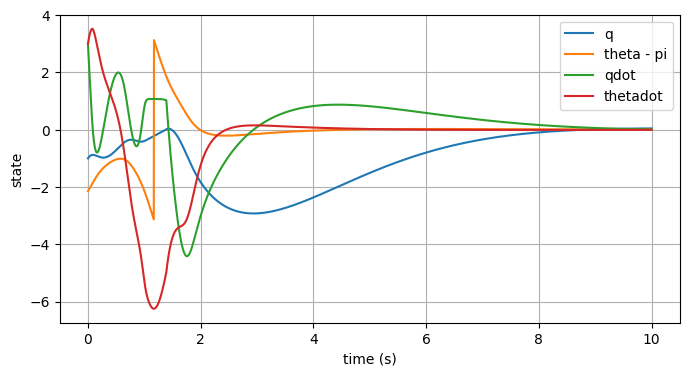

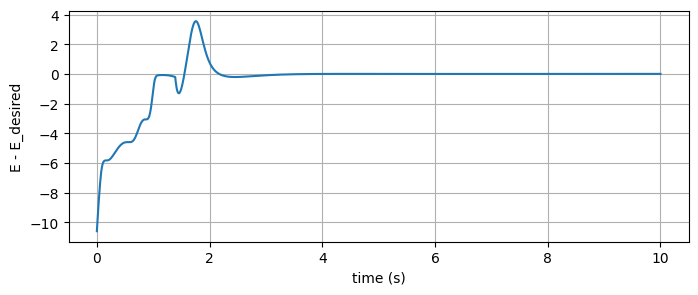

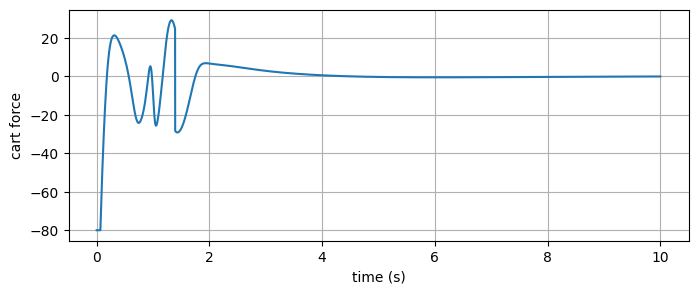

In [19]:
diagram, cartpole = MakeCartPoleSwingUpAndBalanceDiagram(
    rho=100.0,
    kE=4.0,
    kp=1.0,
    kd=2.0,
    force_limit=80.0,
)

x0 = np.array([-1, 1, 3, 3])
state_log, force_log = SimulateCartPole(
    diagram,
    cartpole,
    x0,
    sim_time=10.0,
    show=running_as_notebook,
    record=running_as_notebook,
)

PlotCartPoleLog(state_log, force_log)

## Things to tune

- `rho`: size of the LQR switching region measured by \(x^T S x\).  With the Russ-style \(Q=I, R=I\), `rho=100` roughly includes the cases where pure LQR is still very reliable, but excludes the truly far-away downward configuration.
- `kE`: how aggressively the controller pumps pendulum energy.
- `kp`, `kd`: how hard the controller keeps the cart near the origin during swing-up.
- `force_limit`: actuator saturation.  Too small can cripple the LQR catch; too large makes the visualization less physical.
